In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Load preprocessed data
X_train = np.load('../data/X_train.npy')
X_test = np.load('../data/X_test.npy')
y_train = np.load('../data/y_train.npy')
y_test = np.load('../data/y_test.npy')

# Convert to PyTorch tensors
X_train = torch.tensor(X_train)
X_test = torch.tensor(X_test)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

print("X_train:", X_train.shape)
print("Ready for training!")

X_train: torch.Size([176000, 2, 128])
Ready for training!


In [2]:
class SignalCNN(nn.Module):
    def __init__(self, num_classes=11):
        super(SignalCNN, self).__init__()
        
        self.conv_block = nn.Sequential(
            nn.Conv1d(2, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.5)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 64, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_block(x)
        x = self.classifier(x)
        return x

model = SignalCNN(num_classes=11)
print(model)

SignalCNN(
  (conv_block): Sequential(
    (0): Conv1d(2, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Dropout(p=0.5, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=11, bias=True)
  )
)


In [3]:
# DataLoaders
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Ready to train!")

Ready to train!


In [4]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

print("Training done!")

Epoch 1/10 - Loss: 2.3982
Epoch 2/10 - Loss: 2.3300
Epoch 3/10 - Loss: 2.1723
Epoch 4/10 - Loss: 2.0560
Epoch 5/10 - Loss: 2.0009
Epoch 6/10 - Loss: 1.9563
Epoch 7/10 - Loss: 1.9316
Epoch 8/10 - Loss: 1.9140
Epoch 9/10 - Loss: 1.9025
Epoch 10/10 - Loss: 1.8917
Training done!


In [5]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 33.95%


In [6]:
for epoch in range(10):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+11}/20 - Loss: {avg_loss:.4f}")

print("Done!")

Epoch 11/20 - Loss: 1.8772
Epoch 12/20 - Loss: 1.8610
Epoch 13/20 - Loss: 1.8407
Epoch 14/20 - Loss: 1.8228
Epoch 15/20 - Loss: 1.8096
Epoch 16/20 - Loss: 1.7973
Epoch 17/20 - Loss: 1.7881
Epoch 18/20 - Loss: 1.7730
Epoch 19/20 - Loss: 1.7573
Epoch 20/20 - Loss: 1.7309
Done!


In [7]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 40.32%


In [8]:
torch.save(model.state_dict(), '../models/signal_cnn.pth')
print("Model saved!")

Model saved!


In [9]:
for epoch in range(10):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+21}/30 - Loss: {avg_loss:.4f}")

print("Done!")

Epoch 21/30 - Loss: 1.7047
Epoch 22/30 - Loss: 1.6789
Epoch 23/30 - Loss: 1.6587
Epoch 24/30 - Loss: 1.6461
Epoch 25/30 - Loss: 1.6343
Epoch 26/30 - Loss: 1.6217
Epoch 27/30 - Loss: 1.6104
Epoch 28/30 - Loss: 1.5936
Epoch 29/30 - Loss: 1.5807
Epoch 30/30 - Loss: 1.5727
Done!


In [10]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 44.10%


In [11]:
torch.save(model.state_dict(), '../models/signal_cnn.pth')
print("Model saved!")

Model saved!


In [ ]:
import pickle
import numpy as np

with open('../data/RML2016.10a_dict.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

modulations = sorted(list(set([k[0] for k in data.keys()])))
snrs = sorted(list(set([k[1] for k in data.keys()])))
snr_accuracy = {}

model.eval()
with torch.no_grad():
    for snr in snrs: # loop through each SNR level (-20 to +18)
        X_snr = []
        y_snr = []
        
        for mod in modulations: # for each SNR, collect all 11 modulations
            signals = data[(mod, snr)] # get the 1000 signals for this combo
            for signal in signals:
                X_snr.append(signal)
                y_snr.append(modulations.index(mod)) # convert mod name to number
        
        X_snr = torch.tensor(np.array(X_snr, dtype=np.float32))
        y_snr = torch.tensor(np.array(y_snr))
        
        outputs = model(X_snr)
        _, predicted = torch.max(outputs, 1)
        acc = (predicted == y_snr).float().mean().item() * 100
        snr_accuracy[snr] = acc
        print(f"SNR {snr:4d} dB: {acc:.1f}%")

SNR  -20 dB: 9.2%
SNR  -18 dB: 9.3%
SNR  -16 dB: 9.5%
SNR  -14 dB: 9.8%
SNR  -12 dB: 10.8%
SNR  -10 dB: 14.4%
SNR   -8 dB: 22.5%
SNR   -6 dB: 34.9%
SNR   -4 dB: 52.0%
SNR   -2 dB: 59.7%
SNR    0 dB: 63.3%
SNR    2 dB: 65.5%
SNR    4 dB: 66.4%
SNR    6 dB: 66.3%
SNR    8 dB: 68.1%
SNR   10 dB: 68.0%
SNR   12 dB: 67.7%
SNR   14 dB: 68.3%
SNR   16 dB: 66.0%
SNR   18 dB: 67.1%


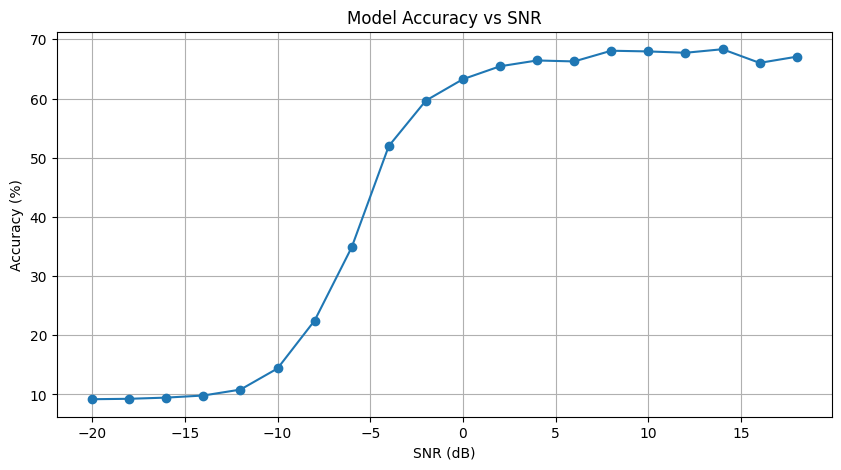

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(list(snr_accuracy.keys()), list(snr_accuracy.values()), marker='o')
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy vs SNR')
plt.grid(True)
plt.show()

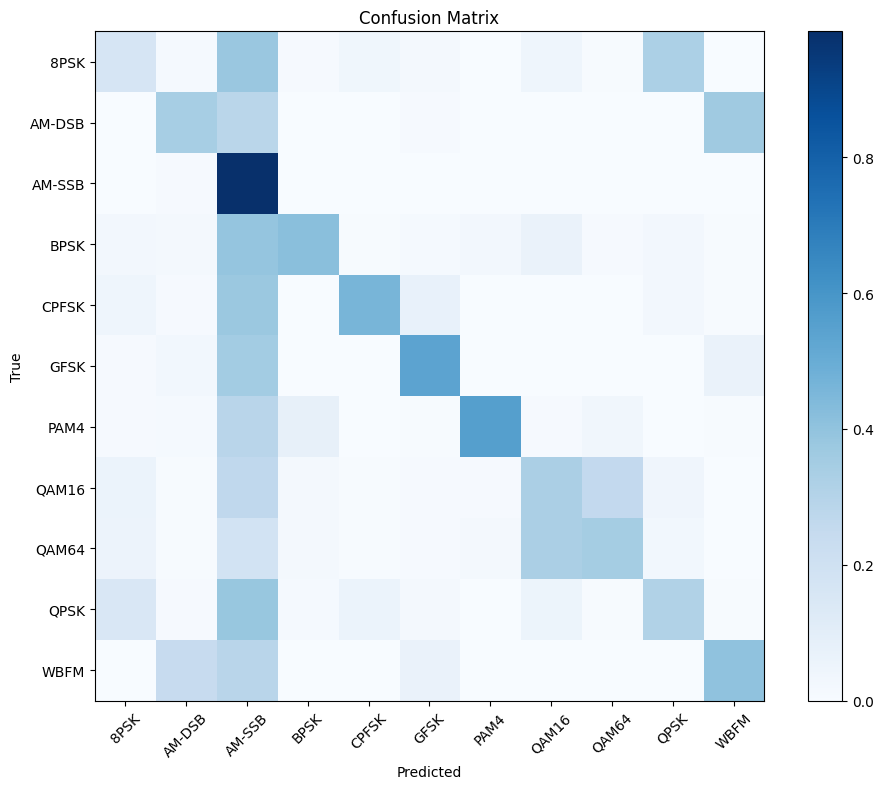

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(y_batch.numpy())

cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
plt.imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar()
plt.xticks(range(11), modulations, rotation=45)
plt.yticks(range(11), modulations)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

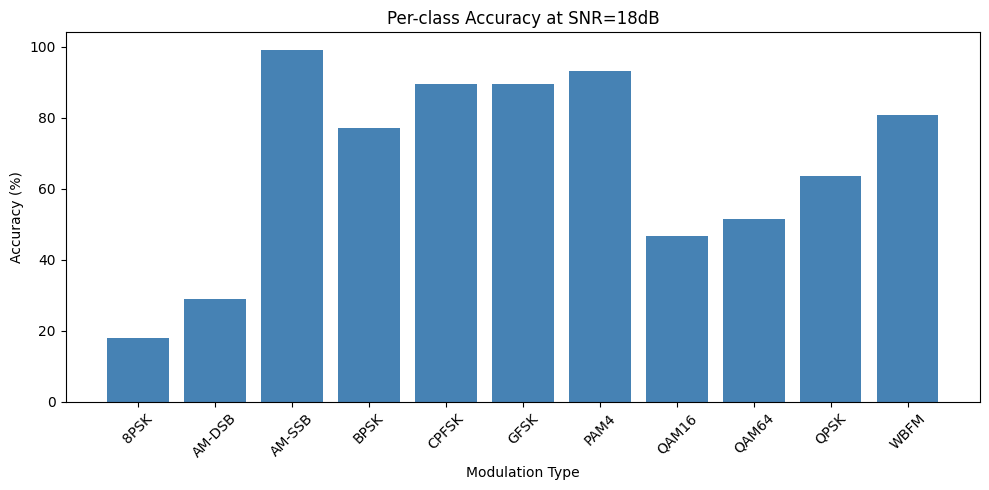

In [16]:
# Goal: test how well the model recognizes each modulation type
# when the signal is clean (SNR=18dB) — best case scenario

class_accuracy = {}

model.eval()  # disable dropout for evaluation
with torch.no_grad():  # no gradient needed, saves memory
    for mod in modulations:  # loop through each of the 11 modulations
        
        # get the 1000 signals for this modulation at 18dB
        signals = data[(mod, 18)]
        
        # convert to tensors
        X_mod = torch.tensor(np.array(signals, dtype=np.float32))
        
        # create 1000 labels all equal to this modulation's index
        y_mod = torch.tensor([modulations.index(mod)] * 1000)
        
        # run the model and get predictions
        outputs = model(X_mod)
        _, predicted = torch.max(outputs, 1)  # pick highest scoring class
        
        # compute accuracy for this modulation only
        acc = (predicted == y_mod).float().mean().item() * 100
        class_accuracy[mod] = acc

# bar chart — each bar = one modulation, height = accuracy at 18dB
plt.figure(figsize=(10, 5))
plt.bar(class_accuracy.keys(), class_accuracy.values(), color='steelblue')
plt.xlabel('Modulation Type')
plt.ylabel('Accuracy (%)')
plt.title('Per-class Accuracy at SNR=18dB')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

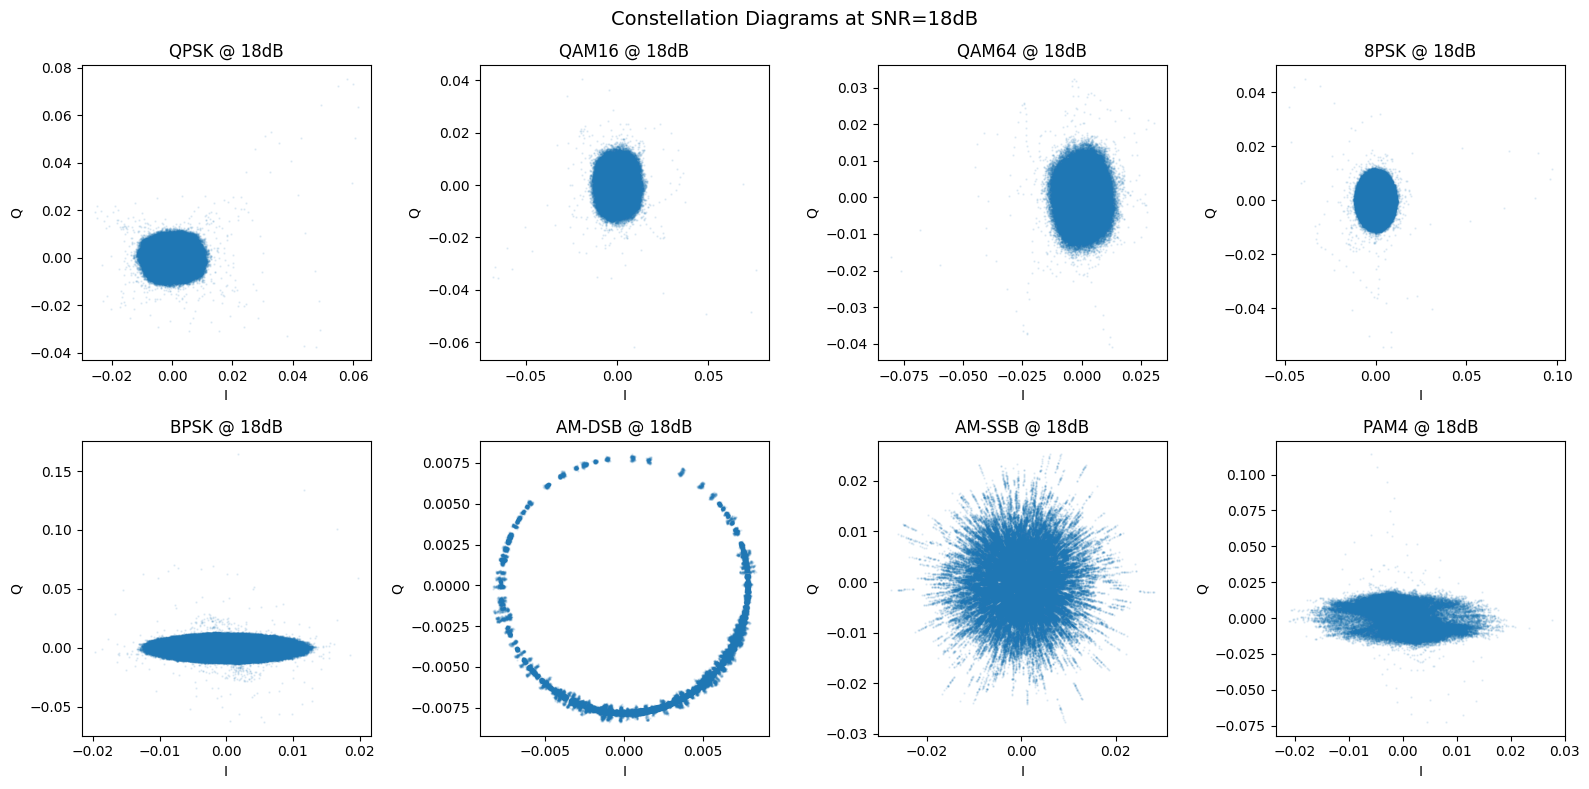

In [17]:
# Goal: visually show why the model confuses certain modulations
# by comparing their constellation diagrams side by side at the same SNR

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
pairs = ['QPSK', 'QAM16', 'QAM64', '8PSK', 'BPSK', 'AM-DSB', 'AM-SSB', 'PAM4']

for ax, mod in zip(axes.flatten(), pairs):
    sample = data[(mod, 18)]
    # plot I vs Q — each dot is one IQ sample
    ax.scatter(sample[:, 0, :], sample[:, 1, :], alpha=0.1, s=0.5)
    ax.set_title(f'{mod} @ 18dB')
    ax.set_xlabel('I')
    ax.set_ylabel('Q')

plt.suptitle('Constellation Diagrams at SNR=18dB', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
# Goal: compare a deeper CNN against our baseline
# to see if more layers actually improve performance

class DeepSignalCNN(nn.Module):
    def __init__(self, num_classes=11):
        super(DeepSignalCNN, self).__init__()
        
        self.conv_block = nn.Sequential(
            nn.Conv1d(2, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.5),
            # extra layers
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.5)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 32, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_block(x)
        x = self.classifier(x)
        return x

deep_model = DeepSignalCNN(num_classes=11)
deep_optimizer = torch.optim.Adam(deep_model.parameters(), lr=0.001)
print(deep_model)

DeepSignalCNN(
  (conv_block): Sequential(
    (0): Conv1d(2, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Dropout(p=0.5, inplace=False)
    (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): ReLU()
    (10): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout(p=0.5, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=11, bias=True)
  )
)


In [20]:
deep_model = DeepSignalCNN(num_classes=11)
deep_optimizer = torch.optim.Adam(deep_model.parameters(), lr=0.0001)

for epoch in range(30):
    deep_model.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        deep_optimizer.zero_grad()
        outputs = deep_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        deep_optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/30 - Loss: {avg_loss:.4f}")

print("Done!")

Epoch 1/30 - Loss: 2.3981
Epoch 2/30 - Loss: 2.2987
Epoch 3/30 - Loss: 2.0774
Epoch 4/30 - Loss: 1.9895
Epoch 5/30 - Loss: 1.9193
Epoch 6/30 - Loss: 1.8725
Epoch 7/30 - Loss: 1.8376
Epoch 8/30 - Loss: 1.8109
Epoch 9/30 - Loss: 1.7906
Epoch 10/30 - Loss: 1.7715
Epoch 11/30 - Loss: 1.7550
Epoch 12/30 - Loss: 1.7402
Epoch 13/30 - Loss: 1.7290
Epoch 14/30 - Loss: 1.7156
Epoch 15/30 - Loss: 1.7084
Epoch 16/30 - Loss: 1.6955
Epoch 17/30 - Loss: 1.6887
Epoch 18/30 - Loss: 1.6792
Epoch 19/30 - Loss: 1.6726
Epoch 20/30 - Loss: 1.6616
Epoch 21/30 - Loss: 1.6547
Epoch 22/30 - Loss: 1.6455
Epoch 23/30 - Loss: 1.6378
Epoch 24/30 - Loss: 1.6279
Epoch 25/30 - Loss: 1.6162
Epoch 26/30 - Loss: 1.6084
Epoch 27/30 - Loss: 1.6029
Epoch 28/30 - Loss: 1.5958
Epoch 29/30 - Loss: 1.5887
Epoch 30/30 - Loss: 1.5793
Done!


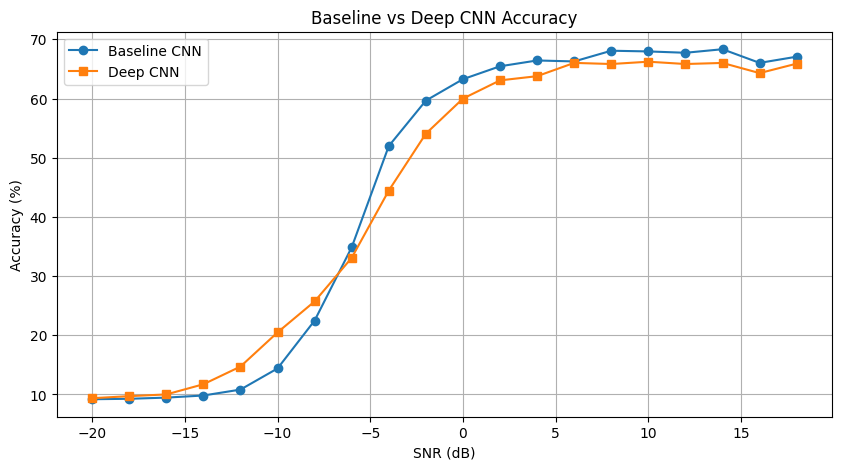

In [21]:
# Goal: compare baseline vs deep model accuracy across all SNR levels

deep_snr_accuracy = {}

deep_model.eval()
with torch.no_grad():
    for snr in snrs:
        X_snr = []
        y_snr = []
        
        for mod in modulations:
            signals = data[(mod, snr)]
            for signal in signals:
                X_snr.append(signal)
                y_snr.append(modulations.index(mod))
        
        X_snr = torch.tensor(np.array(X_snr, dtype=np.float32))
        y_snr = torch.tensor(np.array(y_snr))
        
        outputs = deep_model(X_snr)
        _, predicted = torch.max(outputs, 1)
        acc = (predicted == y_snr).float().mean().item() * 100
        deep_snr_accuracy[snr] = acc

# Plot both curves on same graph
plt.figure(figsize=(10, 5))
plt.plot(list(snr_accuracy.keys()), list(snr_accuracy.values()), 
         marker='o', label='Baseline CNN')
plt.plot(list(deep_snr_accuracy.keys()), list(deep_snr_accuracy.values()), 
         marker='s', label='Deep CNN')
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy (%)')
plt.title('Baseline vs Deep CNN Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
torch.save(deep_model.state_dict(), '../models/deep_signal_cnn.pth')
print("Saved!")

Saved!
